# Bays (2014) Figure 1 d,e,f — GP-Based Equivalent

**Key design:**
- `Population` class (`core.population`) handles encode/decode
- Circular stats (`circular_variance_fisher`, `circular_kurtosis_fisher`) live in `core.decoder.ml_decoder`
- Single simulation cell with `BAYS = True/False` toggle
- No standalone helper functions — everything from core modules

## 💾 Simulation Cache

The three expensive simulation cells (main heatmap, multi-location set-size sweep, multi-set-size heatmap) save their outputs to `./_sim_cache/` keyed on a hash of all relevant parameters (M, N_THETA, N_TRIALS, grid params, TUNING, seeds, …).

**Workflow for re-running this notebook:**

1. The first run populates the cache (slow).
2. Subsequent runs — including kernel restarts — skip the simulation and just load the arrays from disk (fast). All downstream plotting / analysis cells can then be edited and re-run in seconds.
3. If you change any simulation parameter (e.g. `M`, `N_TRIALS`, `TUNING`), the cache key changes automatically and the affected cell recomputes.
4. To force a fresh recompute without changing parameters, set `FORCE_RECOMPUTE = True` in the imports cell, or delete the relevant `.npz` file in `_sim_cache/`.
5. The helper `list_cache()` (called automatically at the top) prints what's currently stored.

**What's cached:**

| Cell | Cache name | Contents |
|------|------------|----------|
| Main simulation loop | `main_heatmap` | `variance_grid`, `kurtosis_grid`, `variance_half`, `exponent_grid` |
| Multi-location set-size sweep | `multiloc_sweep` | per-`l` errors / variance / kurtosis |
| Multi-set-size heatmap experiment | `multi_heatmap` | per-`l` `var`/`kur`/`exp` grids |

All downstream cells (plotting, the quantitative equivalence test, the vector comparison plots) consume these arrays directly and run instantly.


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
import hashlib
import json as _json
import os

from core.population import Population
from core.decoder.ml_decoder import circular_variance_fisher, circular_kurtosis_fisher

print(f"Project root: {PROJECT_ROOT}")

# ============================================================
# Simulation cache infrastructure
# ============================================================
# Expensive simulation cells (the main heatmap and the multi-set-size
# heatmap) save their results to disk keyed on the parameters used.
# Downstream plotting / analysis cells then load these arrays and run
# instantly. To force a fresh recompute, set FORCE_RECOMPUTE = True
# below, or delete the relevant .npz file in CACHE_DIR.

CACHE_DIR = Path.cwd() / "_sim_cache"
CACHE_DIR.mkdir(exist_ok=True)

FORCE_RECOMPUTE = False   # set True to ignore cache and recompute everything

def _hash_key(params: dict) -> str:
    """Deterministic short hash of a dict of parameters."""
    blob = _json.dumps(params, sort_keys=True, default=str).encode()
    return hashlib.md5(blob).hexdigest()[:12]

def cache_path(name: str, params: dict) -> Path:
    """Return the .npz cache path for a named computation + its params."""
    return CACHE_DIR / f"{name}__{_hash_key(params)}.npz"

def load_cache(name: str, params: dict):
    """Return dict of arrays if cache hit, else None."""
    if FORCE_RECOMPUTE:
        return None
    p = cache_path(name, params)
    if not p.exists():
        return None
    try:
        with np.load(p, allow_pickle=True) as data:
            return {k: data[k] for k in data.files}
    except Exception as e:
        print(f"  [cache] failed to load {p.name}: {e}")
        return None

def save_cache(name: str, params: dict, arrays: dict):
    """Save arrays to cache with embedded params metadata."""
    p = cache_path(name, params)
    # Stash params alongside the arrays for traceability.
    payload = dict(arrays)
    payload["_params_json"] = np.array(_json.dumps(params, default=str))
    np.savez_compressed(p, **payload)
    print(f"  [cache] saved {p.name}  ({p.stat().st_size / 1e6:.2f} MB)")

def list_cache():
    """Print all cache entries with their parameter hash."""
    files = sorted(CACHE_DIR.glob("*.npz"))
    if not files:
        print(f"  [cache] (empty) {CACHE_DIR}")
        return
    print(f"  [cache] {CACHE_DIR}:")
    for f in files:
        size_mb = f.stat().st_size / 1e6
        print(f"    {f.name}  ({size_mb:.2f} MB)")

list_cache()


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1
  [cache] /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_equivalence/_sim_cache:
    main_heatmap__1c972bb86f0c.npz  (0.01 MB)
    multi_heatmap__48b97f0a4539.npz  (0.04 MB)
    multiloc_sweep__2833ce636b44.npz  (0.07 MB)


In [2]:
import inspect
src = inspect.getsource(Population.run_trials)
print("Vectorised" if "log_r_pre" in src else "Sequential (OLD)")

Vectorised


## Parameters

**Mapping:** Bays's tuning f = 1/omega gives omega = lambda^2, so lambda = sqrt(omega).
- Small omega (broad tuning) -> small lambda
- Large omega (narrow tuning) -> large lambda

In [3]:
M = 1000           # Population size
N_THETA = 256      # Orientation grid resolution
N_TRIALS = 10000   # 10k with vectorisation
T_D = 0.1          # Decoding window (s)
SIGMA_SQ = 1e-6    # Semi-saturation constant

# ---- Width (x-axis): omega = lambda^2 ----
OMEGA_RANGE = (0.125, 2.5)
LAMBDA_RANGE = (np.sqrt(OMEGA_RANGE[0]),    # 0.354 (broad, low omega)
                np.sqrt(OMEGA_RANGE[1]))     # 1.581 (narrow, high omega)

# ---- Gain (y-axis): gamma_total = gamma_mean * M ----
GAMMA_TOTAL_RANGE = (0.25, 4096)   # Hz, total population gain
GAMMA_RANGE = (GAMMA_TOTAL_RANGE[0] / M,
               GAMMA_TOTAL_RANGE[1] / M)

N_GRID = 20

# Build grids
lambdas = np.logspace(np.log2(LAMBDA_RANGE[0]), np.log2(LAMBDA_RANGE[1]), N_GRID, base=2)
omegas = lambdas**2

gammas = np.logspace(np.log2(GAMMA_RANGE[0]), np.log2(GAMMA_RANGE[1]), N_GRID, base=2)
gammas_total = gammas * M

print(gammas_total)


print(f"Grid: {N_GRID}x{N_GRID}, {N_TRIALS:,} trials each")
print(f"lambda range:       [{LAMBDA_RANGE[0]:.3f}, {LAMBDA_RANGE[1]:.3f}]")
print(f"omega = lambda^2:   [{omegas[0]:.3f}, {omegas[-1]:.3f}]")
print(f"gamma_total range:  [{gammas_total[0]:.2f}, {gammas_total[-1]:.1f}] Hz")

[2.50000000e-01 4.16631003e-01 6.94325571e-01 1.15711024e+00
 1.92835200e+00 3.21364491e+00 5.35561640e+00 8.92526334e+00
 1.48741657e+01 2.47881543e+01 4.13100543e+01 6.88441975e+01
 1.14730508e+02 1.91201147e+02 3.18641303e+02 5.31023383e+02
 8.84963219e+02 1.47481245e+03 2.45781037e+03 4.09600000e+03]
Grid: 20x20, 10,000 trials each
lambda range:       [0.354, 1.581]
omega = lambda^2:   [0.125, 2.500]
gamma_total range:  [0.25, 4096.0] Hz


## Main Simulation Loop

**Set `BAYS = True`** for Bays (2014) Eq. 1 parametric tuning.
**Set `BAYS = False`** for GP-based tuning.

In [4]:
# ---- Toggle BAYS vs GP ----
BAYS = False
TUNING = 'bays' if BAYS else 'gp'
SEED = 42

# Build a parameter dict that uniquely identifies this computation.
# If ANY of these change, the cache key changes and we recompute.
_main_params = {
    "M": M,
    "N_THETA": N_THETA,
    "N_TRIALS": N_TRIALS,
    "T_D": T_D,
    "SIGMA_SQ": SIGMA_SQ,
    "N_GRID": N_GRID,
    "OMEGA_RANGE": list(OMEGA_RANGE),
    "GAMMA_TOTAL_RANGE": list(GAMMA_TOTAL_RANGE),
    "TUNING": TUNING,
    "SEED": SEED,
}

_cached = load_cache("main_heatmap", _main_params)

if _cached is not None:
    variance_grid = _cached["variance_grid"]
    kurtosis_grid = _cached["kurtosis_grid"]
    variance_half = _cached["variance_half"]
    exponent_grid = _cached["exponent_grid"]
    print(f"  [cache HIT] main_heatmap  (TUNING={TUNING})")
    print(f"  Loaded variance_grid {variance_grid.shape}, "
          f"kurtosis_grid {kurtosis_grid.shape}, "
          f"exponent_grid {exponent_grid.shape}")
else:
    print(f"  [cache MISS] main_heatmap  (TUNING={TUNING}) — recomputing…")
    t0 = time.time()
    variance_grid = np.full((N_GRID, N_GRID), np.nan)
    kurtosis_grid = np.full((N_GRID, N_GRID), np.nan)
    variance_half = np.full((N_GRID, N_GRID), np.nan)

    for i, omega in enumerate(omegas):
        lam = np.sqrt(omega) if TUNING == 'gp' else omega
        t_pop = time.time()
        pop = Population(M, N_THETA, lam if TUNING == 'gp' else omega,
                         tuning_type=TUNING, seed=SEED + i * 1000)
        print(f"    Population built in {time.time() - t_pop:.1f}s")
        for j, gam in enumerate(gammas):
            rng = np.random.RandomState(SEED + i * N_GRID + j)
            errors = pop.run_trials(
                N_TRIALS, gam, T_D, set_size=1, sigma_sq=SIGMA_SQ, rng=rng)
            variance_grid[j, i] = circular_variance_fisher(errors)
            kurtosis_grid[j, i] = circular_kurtosis_fisher(errors)

            rng2 = np.random.RandomState(SEED + i * N_GRID + j + N_GRID**2)
            errors_half = pop.run_trials(
                N_TRIALS, gam / 2, T_D, set_size=1, sigma_sq=SIGMA_SQ, rng=rng2)
            variance_half[j, i] = circular_variance_fisher(errors_half)

        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (N_GRID - i - 1)
        print(f"  [{TUNING}] ω={omega:.3f} (λ={lam:.3f}) done  "
          f"[{i+1}/{N_GRID}, {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining]")

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(variance_half > 1e-15, variance_grid / variance_half, np.nan)
        exponent_grid = np.where(ratio > 0, np.log2(ratio), np.nan)

    print(f"\nDone in {time.time() - t0:.1f}s  (tuning: {TUNING})")

    save_cache("main_heatmap", _main_params, {
        "variance_grid": variance_grid,
        "kurtosis_grid": kurtosis_grid,
        "variance_half": variance_half,
        "exponent_grid": exponent_grid,
    })


  [cache HIT] main_heatmap  (TUNING=gp)
  Loaded variance_grid (20, 20), kurtosis_grid (20, 20), exponent_grid (20, 20)


## Plot (omega on x-axis, gamma_total on y-axis)

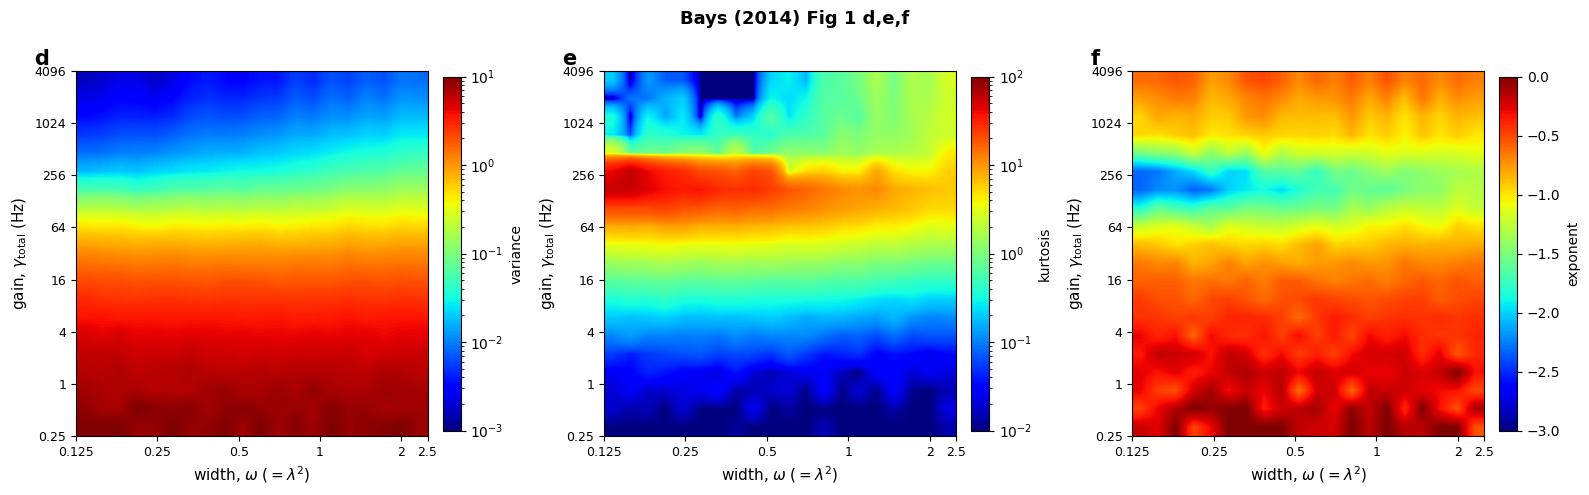

Variance range:  [0.0017, 12.2830]
Kurtosis range:  [-0.4892, 58.3018]
Exponent range:  [-2.3470, 0.3786]


In [5]:
var_plot = variance_grid
kur_plot = kurtosis_grid
exp_plot = exponent_grid

ext = [
    np.log2(omegas[0]), np.log2(omegas[-1]),
    np.log2(gammas_total[0]), np.log2(gammas_total[-1]),
]


def fmt_ax(ax, label):
    ax.set_xlabel(r'width, $\omega\;(= \lambda^2)$', fontsize=11)
    omega_ticks = np.array([0.125, 0.25, 0.5, 1, 2, 2.5])
    omega_ticks = omega_ticks[(omega_ticks >= omegas[0] * 0.9) &
                              (omega_ticks <= omegas[-1] * 1.1)]
    ax.set_xticks(np.log2(omega_ticks))
    ax.set_xticklabels([f'{v:g}' for v in omega_ticks], fontsize=9)

    ax.set_ylabel(r'gain, $\gamma_{\mathrm{total}}$ (Hz)', fontsize=11)
    gamma_ticks = np.array([0.25, 1, 4, 16, 64, 256, 1024, 4096])
    gamma_ticks = gamma_ticks[(gamma_ticks >= gammas_total[0] * 0.9) &
                              (gamma_ticks <= gammas_total[-1] * 1.1)]
    ax.set_yticks(np.log2(gamma_ticks))
    ax.set_yticklabels([f'{v:g}' for v in gamma_ticks], fontsize=9)

    ax.text(-0.12, 1.06, f'$\\mathbf{{{label}}}$',
            transform=ax.transAxes, fontsize=15, fontweight='bold', va='top')


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(
    np.clip(var_plot, 0.001, 10),
    origin='lower', aspect='auto', extent=ext,
    norm=mcolors.LogNorm(vmin=0.001, vmax=10),
    cmap='jet', interpolation='bilinear')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04).set_label('variance')
fmt_ax(axes[0], 'd')

im1 = axes[1].imshow(
    np.clip(kur_plot, 0.01, 100),
    origin='lower', aspect='auto', extent=ext,
    norm=mcolors.LogNorm(vmin=0.01, vmax=100),
    cmap='jet', interpolation='bilinear')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04).set_label('kurtosis')
fmt_ax(axes[1], 'e')

im2 = axes[2].imshow(
    np.clip(exp_plot, -3, 0),
    origin='lower', aspect='auto', extent=ext,
    vmin=-3, vmax=0,
    cmap='jet', interpolation='bilinear')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04).set_label('exponent')
fmt_ax(axes[2], 'f')

fig.suptitle('Bays (2014) Fig 1 d,e,f', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bays_fig1_def.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance range:  [{np.nanmin(variance_grid):.4f}, {np.nanmax(variance_grid):.4f}]")
print(f"Kurtosis range:  [{np.nanmin(kurtosis_grid):.4f}, {np.nanmax(kurtosis_grid):.4f}]")
print(f"Exponent range:  [{np.nanmin(exponent_grid):.4f}, {np.nanmax(exponent_grid):.4f}]")

## Multi-Location Set Size Sweep

Runs encode -> DN -> spike -> factorised ML decode at set sizes l = {1, 2, 4, 8}.

- **BAYS mode (L=1):** set-size effect via gamma_eff = gamma / l
- **GP mode (L>1):** actual multi-location DN + factorised marginalisation

In [8]:
if _cached_ml is not None:
    print(f"  [cache HIT] multiloc_sweep  (TUNING={TUNING})")
    multi_results = {}
    for l in SET_SIZES:
        multi_results[l] = {
            "errors":   _cached_ml[f"l{l}_errors"],
            "variance": float(_cached_ml[f"l{l}_variance"]),
            "kurtosis": float(_cached_ml[f"l{l}_kurtosis"]),
        }
    print(f"  Loaded results for set sizes {SET_SIZES}")

    # Rebuild Population only if needed by downstream cells.
    # This is the slow step (M × L Cholesky decompositions) — skip
    # unless something actually uses pop_multi.
    REBUILD_POP_MULTI = False
    if REBUILD_POP_MULTI:
        print("  Rebuilding Population (this can take several minutes "
              f"at M={M}, N_THETA={N_THETA}, L={N_LOCATIONS})...")
        t_pop = time.time()
        pop_multi = Population(
            M, N_THETA, width_param,
            tuning_type=TUNING,
            n_locations=N_LOCATIONS,
            seed=SEED_MULTI,
        )
        print(f"  Population built in {time.time() - t_pop:.1f}s: {pop_multi}")
    print(f"gamma_total = {GAMMA_TOTAL_FITTED} Hz  "
          f"(gamma_mean = {gamma_fitted:.6f} Hz/neuron)")

  [cache HIT] multiloc_sweep  (TUNING=gp)
  Loaded results for set sizes [1, 2, 4, 8]
gamma_total = 119.0 Hz  (gamma_mean = 0.119000 Hz/neuron)


## Effective Gain Overlay — Set Size Lines on Heatmaps

Under DN, storing l items at gamma_total is equivalent to a single item at gamma_eff = gamma_total / l.
The horizontal lines show where each set size lives on the heatmap.

  l=1:  γ_eff = 119.0 Hz  (log₂ = 6.89)  in range
  l=2:  γ_eff = 59.5 Hz  (log₂ = 5.89)  in range
  l=4:  γ_eff = 29.8 Hz  (log₂ = 4.89)  in range
  l=8:  γ_eff = 14.9 Hz  (log₂ = 3.89)  in range


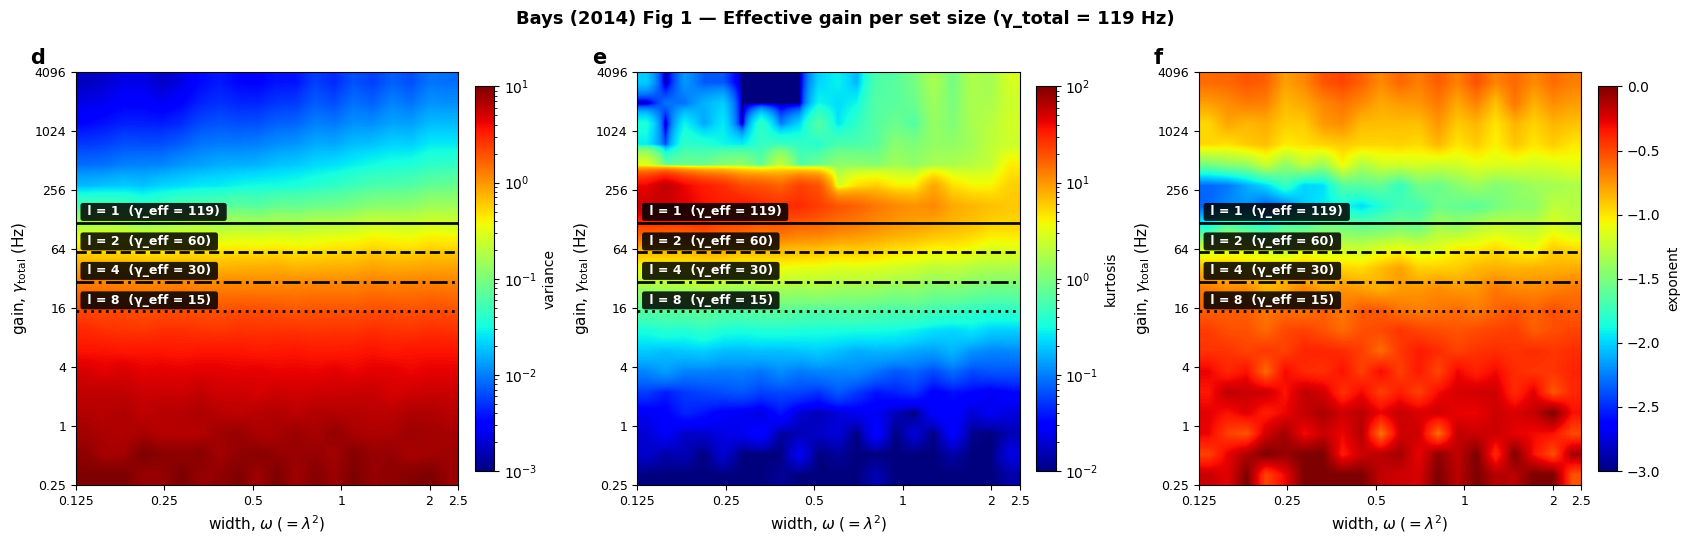

In [9]:
gamma_effs = {l: GAMMA_TOTAL_FITTED / l for l in SET_SIZES}

# All lines black; differentiate set sizes by linestyle.
line_color  = 'black'
line_styles = {1: '-', 2: '--', 4: '-.', 8: ':'}
line_widths = {1: 2.0, 2: 2.0, 4: 2.0, 8: 2.0}

y_lo, y_hi = gammas_total[0], gammas_total[-1]
for l, g_eff in gamma_effs.items():
    status = "in range" if y_lo <= g_eff <= y_hi else "OUT OF RANGE"
    print(f"  l={l}:  γ_eff = {g_eff:.1f} Hz  (log₂ = {np.log2(g_eff):.2f})  {status}")


def add_set_size_lines(ax, xlims):
    for l in SET_SIZES:
        g_eff = gamma_effs[l]
        if y_lo <= g_eff <= y_hi:
            y_pos = np.log2(g_eff)
            ax.axhline(y=y_pos, color=line_color, linestyle=line_styles[l],
                       linewidth=line_widths[l], alpha=0.95, zorder=5)
            # Label inside plot, left-aligned with a black badge
            ax.text(xlims[0] + 0.08, y_pos + 0.15,
                    f' l = {l}  (γ_eff = {g_eff:.0f}) ',
                    color='white', fontsize=9, fontweight='bold',
                    va='bottom', ha='left', zorder=6,
                    bbox=dict(boxstyle='round,pad=0.2', fc=line_color,
                              ec='none', alpha=0.85))


fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

im0 = axes[0].imshow(
    np.clip(var_plot, 0.001, 10),
    origin='lower', aspect='auto', extent=ext,
    norm=mcolors.LogNorm(vmin=0.001, vmax=10),
    cmap='jet', interpolation='bilinear')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04).set_label('variance')
fmt_ax(axes[0], 'd')
add_set_size_lines(axes[0], ext[:2])

im1 = axes[1].imshow(
    np.clip(kur_plot, 0.01, 100),
    origin='lower', aspect='auto', extent=ext,
    norm=mcolors.LogNorm(vmin=0.01, vmax=100),
    cmap='jet', interpolation='bilinear')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04).set_label('kurtosis')
fmt_ax(axes[1], 'e')
add_set_size_lines(axes[1], ext[:2])

im2 = axes[2].imshow(
    np.clip(exp_plot, -3, 0),
    origin='lower', aspect='auto', extent=ext,
    vmin=-3, vmax=0,
    cmap='jet', interpolation='bilinear')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04).set_label('exponent')
fmt_ax(axes[2], 'f')
add_set_size_lines(axes[2], ext[:2])

fig.suptitle(
    f'Bays (2014) Fig 1 — Effective gain per set size '
    f'(γ_total = {GAMMA_TOTAL_FITTED:.0f} Hz)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bays_fig1_def_setsize_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


## Part 2: Multi-Set-Size Heatmap Experiment

**Goal:** Test whether the Bays equivalence (l items at γ ≡ 1 item at γ/l) holds for the GP model.

**Design:**
- **4 rows** (l = 1, 2, 4, 8) × **3 columns** (variance, kurtosis, exponent)
- Each row is a full (ω, γ) heatmap computed by running the **actual** multi-item pipeline at that set size
- All rows use the **same underlying population** (same GP samples) per ω column
- **Row 1 (l=1):** horizontal lines at γ\_eff = γ\_total/l mark the Bays predictions
- **Rows 2–4:** single black line at γ\_total = 114.73 Hz (grid index 12)

**Quantitative test (at γ\_total = 114.73 Hz):**
- **Vector A** (Bays prediction): l=1 heatmap row at γ\_eff = γ\_total/l
- **Vector B** (actual): l-th heatmap row at γ\_total
- Compare via Pearson correlation and mean absolute error

In Bays's model, A = B exactly. In the GP model, deviations reveal how mixed selectivity and shared populations create a more nuanced resource division.

In [10]:
# ---- Multi-set-size heatmap computation ----
# Recomputes ALL set sizes with consistent populations (L=8 for GP, L=1 for Bays)

N_LOCATIONS_HEATMAP = 8
SET_SIZES_HEATMAP = [1, 2, 4, 8]
GAMMA_REF_IDX = 12  # γ_total = 114.73 Hz (exact grid point)
SEED_MULTI_HEATMAP = 42

print(f"Reference γ_total = {gammas_total[GAMMA_REF_IDX]:.2f} Hz (index {GAMMA_REF_IDX})")
print(f"Set sizes: {SET_SIZES_HEATMAP}")
print(f"Grid: {N_GRID}×{N_GRID}, {N_TRIALS:,} trials per pixel")
print(f"Tuning mode: {TUNING}")
print()

# Cache key for this computation.
_multi_params = {
    "M": M,
    "N_THETA": N_THETA,
    "N_TRIALS": N_TRIALS,
    "T_D": T_D,
    "SIGMA_SQ": SIGMA_SQ,
    "N_GRID": N_GRID,
    "OMEGA_RANGE": list(OMEGA_RANGE),
    "GAMMA_TOTAL_RANGE": list(GAMMA_TOTAL_RANGE),
    "TUNING": TUNING,
    "N_LOCATIONS_HEATMAP": N_LOCATIONS_HEATMAP,
    "SET_SIZES_HEATMAP": list(SET_SIZES_HEATMAP),
    "SEED_MULTI_HEATMAP": SEED_MULTI_HEATMAP,
}

_cached_multi = load_cache("multi_heatmap", _multi_params)

if _cached_multi is not None:
    print(f"  [cache HIT] multi_heatmap  (TUNING={TUNING})")
    heatmaps = {}
    for l in SET_SIZES_HEATMAP:
        heatmaps[l] = {
            "var": _cached_multi[f"l{l}_var"],
            "kur": _cached_multi[f"l{l}_kur"],
            "exp": _cached_multi[f"l{l}_exp"],
        }
    print(f"  Loaded heatmaps for set sizes {SET_SIZES_HEATMAP}")
else:
    print(f"  [cache MISS] multi_heatmap  (TUNING={TUNING}) — recomputing…")
    # Storage: heatmaps[l] = {'var': ..., 'kur': ..., 'exp': ...}
    heatmaps = {}

    t0_all = time.time()

    for l in SET_SIZES_HEATMAP:
        var_grid_l = np.full((N_GRID, N_GRID), np.nan)
        kur_grid_l = np.full((N_GRID, N_GRID), np.nan)
        var_half_l = np.full((N_GRID, N_GRID), np.nan)

        t0_l = time.time()
        print(f"{'='*60}")
        print(f"  Set size l = {l}")
        print(f"{'='*60}")

        for i, omega in enumerate(omegas):
            # Create population: same seed per omega column across all l values
            width_param = np.sqrt(omega) if TUNING == 'gp' else omega
            pop = Population(
                M, N_THETA, width_param,
                tuning_type=TUNING,
                n_locations=N_LOCATIONS_HEATMAP if TUNING == 'gp' else 1,
                seed=SEED_MULTI_HEATMAP + i * 1000,
            )

            for j, gam in enumerate(gammas):
                # Different RNG seeds for different l values
                rng  = np.random.RandomState(
                    SEED_MULTI_HEATMAP + l * 100000 + i * N_GRID + j)
                rng2 = np.random.RandomState(
                    SEED_MULTI_HEATMAP + l * 100000 + i * N_GRID + j + N_GRID**2)

                if pop.L == 1:
                    # Bays (L=1): γ_eff = γ/l shortcut
                    errors = pop.run_trials(
                        N_TRIALS, gam / l, T_D,
                        set_size=1, sigma_sq=SIGMA_SQ, rng=rng)
                    errors_half = pop.run_trials(
                        N_TRIALS, gam / (2 * l), T_D,
                        set_size=1, sigma_sq=SIGMA_SQ, rng=rng2)
                else:
                    # GP (L>1): full multi-item pipeline
                    errors = pop.run_trials(
                        N_TRIALS, gam, T_D,
                        set_size=l, sigma_sq=SIGMA_SQ, rng=rng)
                    errors_half = pop.run_trials(
                        N_TRIALS, gam / 2, T_D,
                        set_size=l, sigma_sq=SIGMA_SQ, rng=rng2)

                var_grid_l[j, i] = circular_variance_fisher(errors)
                kur_grid_l[j, i] = circular_kurtosis_fisher(errors)
                var_half_l[j, i] = circular_variance_fisher(errors_half)

            elapsed_l = time.time() - t0_l
            eta_l = elapsed_l / (i + 1) * (N_GRID - i - 1)
            print(f"    [{TUNING}] l={l}, ω={omega:.3f} (λ={width_param:.3f})  "
                  f"[{i+1}/{N_GRID}, {elapsed_l:.0f}s elapsed, ~{eta_l:.0f}s remaining]")

        # Compute exponent grid
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio_l = np.where(var_half_l > 1e-15, var_grid_l / var_half_l, np.nan)
            exp_grid_l = np.where(ratio_l > 0, np.log2(ratio_l), np.nan)

        heatmaps[l] = {'var': var_grid_l, 'kur': kur_grid_l, 'exp': exp_grid_l}

        elapsed_total = time.time() - t0_all
        print(f"  l={l} done in {time.time() - t0_l:.0f}s  "
              f"(total elapsed: {elapsed_total:.0f}s)")
        print()

    print(f"\nAll set sizes done in {time.time() - t0_all:.0f}s")

    # Save all set sizes into one .npz
    _save_payload = {}
    for l in SET_SIZES_HEATMAP:
        _save_payload[f"l{l}_var"] = heatmaps[l]["var"]
        _save_payload[f"l{l}_kur"] = heatmaps[l]["kur"]
        _save_payload[f"l{l}_exp"] = heatmaps[l]["exp"]
    save_cache("multi_heatmap", _multi_params, _save_payload)


Reference γ_total = 114.73 Hz (index 12)
Set sizes: [1, 2, 4, 8]
Grid: 20×20, 10,000 trials per pixel
Tuning mode: gp

  [cache HIT] multi_heatmap  (TUNING=gp)
  Loaded heatmaps for set sizes [1, 2, 4, 8]


## Multi-Set-Size Heatmap Figure

- **Row 1 (l=1):** single-item heatmap + horizontal lines at γ/l for l=1,2,4,8
- **Rows 2–4:** actual multi-item heatmaps + black line at γ\_total = 114.73 Hz
- Bays's prediction: row l at the black line should match row 1 at the l-th horizontal line

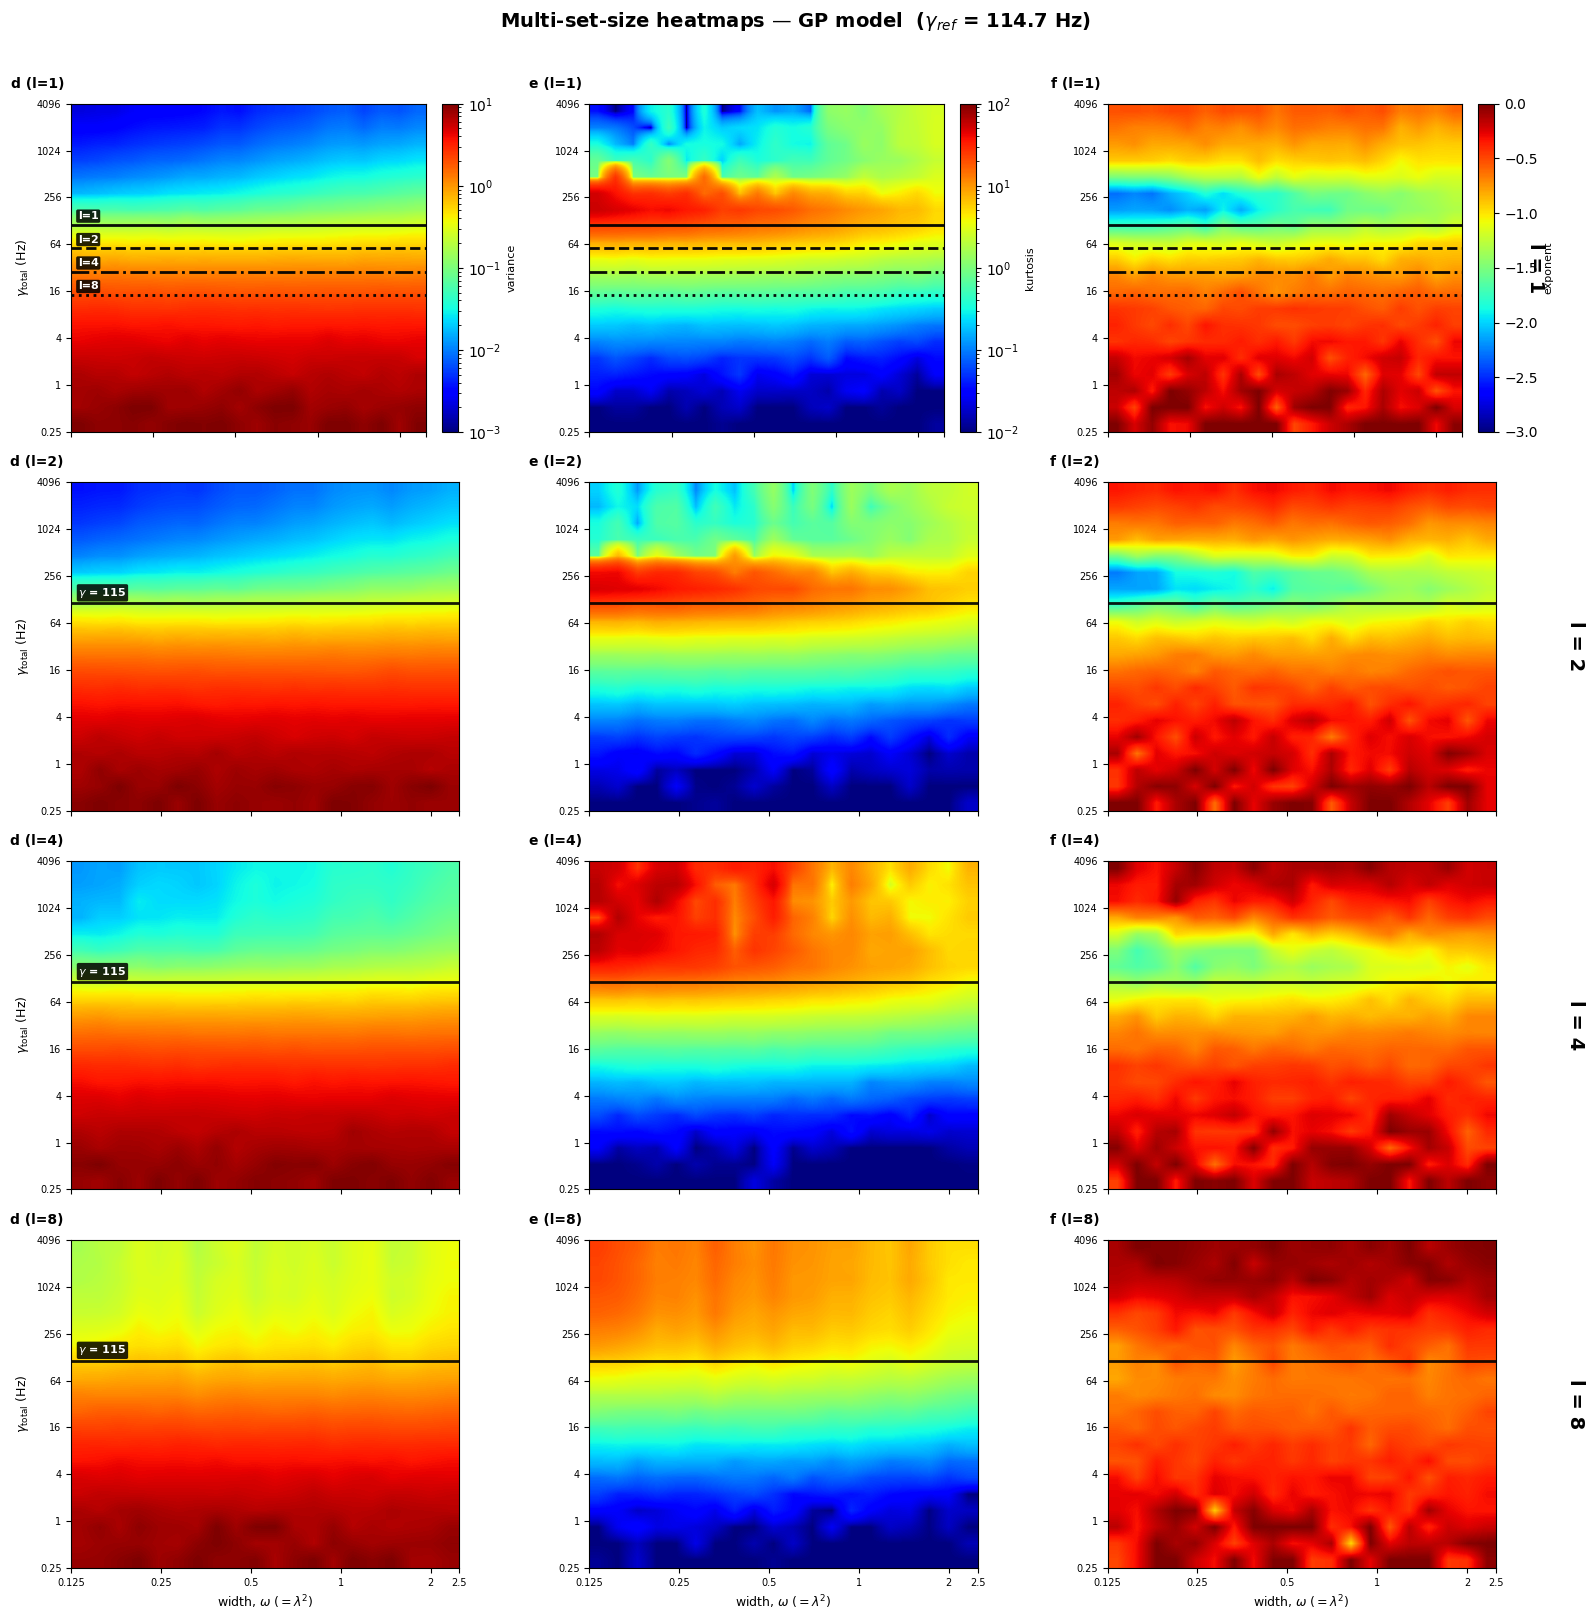

In [11]:
# ---- 4-row × 3-column figure ----
#
# Color-limit policy (item 2):
#   vmin/vmax are SHARED across all rows in each column.
#   This means the same color encodes the same value in every row.
#   The colorbar (shown only on row 0) therefore applies to every row.
#
# Overlay-line policy (item 1):
#   All horizontal lines are black; set sizes differ by linestyle only.

# Shared plotting parameters
ext = [
    np.log2(omegas[0]), np.log2(omegas[-1]),
    np.log2(gammas_total[0]), np.log2(gammas_total[-1]),
]

gamma_ref = gammas_total[GAMMA_REF_IDX]

# Per-column color limits (shared across rows)
VAR_VMIN, VAR_VMAX = 0.001, 10
KUR_VMIN, KUR_VMAX = 0.01,  100
EXP_VMIN, EXP_VMAX = -3,    0

# Formatting helper
def fmt_ax_multi(ax, label, show_xlabel=True, show_ylabel=True):
    if show_xlabel:
        ax.set_xlabel(r'width, $\omega\;(= \lambda^2)$', fontsize=9)
    omega_ticks = np.array([0.125, 0.25, 0.5, 1, 2, 2.5])
    omega_ticks = omega_ticks[(omega_ticks >= omegas[0] * 0.9) &
                              (omega_ticks <= omegas[-1] * 1.1)]
    ax.set_xticks(np.log2(omega_ticks))
    ax.set_xticklabels([f'{v:g}' for v in omega_ticks], fontsize=7)
    if not show_xlabel:
        ax.set_xticklabels([])

    if show_ylabel:
        ax.set_ylabel(r'$\gamma_{\mathrm{total}}$ (Hz)', fontsize=9)
    gamma_ticks = np.array([0.25, 1, 4, 16, 64, 256, 1024, 4096])
    gamma_ticks = gamma_ticks[(gamma_ticks >= gammas_total[0] * 0.9) &
                              (gamma_ticks <= gammas_total[-1] * 1.1)]
    ax.set_yticks(np.log2(gamma_ticks))
    ax.set_yticklabels([f'{v:g}' for v in gamma_ticks], fontsize=7)

    if label:
        ax.text(-0.02, 1.04, label, transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='bottom', ha='right')


# Linestyles for row 1 (Bays prediction lines) — all black, differ by dash.
overlay_styles = {1: '-', 2: '--', 4: '-.', 8: ':'}
OVERLAY_COLOR  = 'black'

nrows = len(SET_SIZES_HEATMAP)
fig, axes = plt.subplots(nrows, 3, figsize=(16, 4 * nrows))

for row_idx, l in enumerate(SET_SIZES_HEATMAP):
    is_bottom = (row_idx == nrows - 1)
    data = heatmaps[l]

    # --- Variance ---
    ax = axes[row_idx, 0]
    im = ax.imshow(
        np.clip(data['var'], VAR_VMIN, VAR_VMAX),
        origin='lower', aspect='auto', extent=ext,
        norm=mcolors.LogNorm(vmin=VAR_VMIN, vmax=VAR_VMAX),
        cmap='jet', interpolation='bilinear')
    if row_idx == 0:
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label(
            'variance', fontsize=8)
    fmt_ax_multi(ax, f'd (l={l})', show_xlabel=is_bottom)

    # --- Kurtosis ---
    ax = axes[row_idx, 1]
    im = ax.imshow(
        np.clip(data['kur'], KUR_VMIN, KUR_VMAX),
        origin='lower', aspect='auto', extent=ext,
        norm=mcolors.LogNorm(vmin=KUR_VMIN, vmax=KUR_VMAX),
        cmap='jet', interpolation='bilinear')
    if row_idx == 0:
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label(
            'kurtosis', fontsize=8)
    fmt_ax_multi(ax, f'e (l={l})', show_xlabel=is_bottom, show_ylabel=False)

    # --- Exponent ---
    ax = axes[row_idx, 2]
    im = ax.imshow(
        np.clip(data['exp'], EXP_VMIN, EXP_VMAX),
        origin='lower', aspect='auto', extent=ext,
        vmin=EXP_VMIN, vmax=EXP_VMAX,
        cmap='jet', interpolation='bilinear')
    if row_idx == 0:
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label(
            'exponent', fontsize=8)
    fmt_ax_multi(ax, f'f (l={l})', show_xlabel=is_bottom, show_ylabel=False)

    # ---- Overlay lines (all black) ----
    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        if row_idx == 0:
            # Row 1: horizontal lines at γ_eff = γ_ref/l for each set size,
            # all black, differentiated by linestyle.
            for ll in SET_SIZES_HEATMAP:
                g_eff = gamma_ref / ll
                if gammas_total[0] <= g_eff <= gammas_total[-1]:
                    y_pos = np.log2(g_eff)
                    ax.axhline(y=y_pos, color=OVERLAY_COLOR,
                               linestyle=overlay_styles[ll],
                               linewidth=2.0, alpha=0.95, zorder=5)
                    if col_idx == 0:
                        ax.text(
                            ext[0] + 0.08, y_pos + 0.15,
                            f'l={ll}', color='white', fontsize=8,
                            fontweight='bold', va='bottom', ha='left',
                            zorder=6,
                            bbox=dict(boxstyle='round,pad=0.15',
                                      fc=OVERLAY_COLOR,
                                      ec='none', alpha=0.85))
        else:
            # Rows 2–4: single black line at γ_ref
            y_pos = np.log2(gamma_ref)
            ax.axhline(y=y_pos, color=OVERLAY_COLOR, linestyle='-',
                       linewidth=2.0, alpha=0.9, zorder=5)
            if col_idx == 0:
                ax.text(
                    ext[0] + 0.08, y_pos + 0.15,
                    f'$\gamma$ = {gamma_ref:.0f}', color='white',
                    fontsize=8, fontweight='bold', va='bottom', ha='left',
                    zorder=6,
                    bbox=dict(boxstyle='round,pad=0.15',
                              fc=OVERLAY_COLOR, ec='none', alpha=0.85))

    # Row label on the right
    axes[row_idx, 2].text(
        1.18, 0.5, f'l = {l}',
        transform=axes[row_idx, 2].transAxes,
        fontsize=14, fontweight='bold', va='center', rotation=-90)

fig.suptitle(
    f'Multi-set-size heatmaps — {TUNING.upper()} model  '
    f'($\gamma_{{ref}}$ = {gamma_ref:.1f} Hz)',
    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'fig1_multisetsize_{TUNING}.png', dpi=150, bbox_inches='tight')
plt.show()


## Quantitative Equivalence Test

**Does l items at γ ≡ 1 item at γ/l?**

For each set size l ∈ {2, 4, 8} at the reference γ\_total = 114.73 Hz:
- **Vector A** (Bays prediction): extract row from the l=1 heatmap at γ\_eff = γ\_total/l (nearest grid point)
- **Vector B** (actual GP result): extract row from the l-th heatmap at γ\_total

Both vectors have N\_GRID entries (one per ω). We compare them via:
1. **Pearson correlation** — do they have the same shape across ω?
2. **Mean absolute error** — how far apart are the actual values?

In [12]:
# ---- Quantitative equivalence test (Candidate A, interpolated) ----
#
# Bays equivalence: l items at γ_ref behaves like 1 item at γ_ref/l.
#
#   Prediction  (Bays):  heatmaps[1] interpolated at γ_eff = γ_ref / l
#   Measurement (GP):    heatmaps[l] row at γ_ref           (always same row)
#
# Both vectors are over omega (length N_GRID).
# We INTERPOLATE the prediction along the log-gain axis so we hit γ_ref/l
# exactly, instead of snapping to the nearest grid point.

from scipy.stats import pearsonr

gamma_ref = gammas_total[GAMMA_REF_IDX]
log2_gammas = np.log2(gammas_total)

print(f"Reference: γ_ref = {gamma_ref:.2f} Hz (grid index {GAMMA_REF_IDX})")
print(f"Tuning mode: {TUNING}")
print()


def interp_row_at_gain(grid, target_gain):
    """
    Linearly interpolate a heatmap (gamma × omega) along the log2-gain axis
    at `target_gain` Hz. Returns a length-N_GRID vector over omega.
    Linear-in-log2(gamma) matches how the gain grid was constructed.
    """
    target_log = np.log2(target_gain)
    if target_log <= log2_gammas[0]:
        return grid[0, :].copy()
    if target_log >= log2_gammas[-1]:
        return grid[-1, :].copy()
    j_hi = np.searchsorted(log2_gammas, target_log)
    j_lo = j_hi - 1
    w = (target_log - log2_gammas[j_lo]) / (log2_gammas[j_hi] - log2_gammas[j_lo])
    return (1 - w) * grid[j_lo, :] + w * grid[j_hi, :]


# Confirm the target γ_eff per set size and that interpolation lands on it.
target_gains = {}
for l in [2, 4, 8]:
    g_eff = gamma_ref / l
    target_gains[l] = g_eff
    print(f"  l={l}: γ_eff = γ_ref/l = {g_eff:.3f} Hz "
          f"(interpolated, no grid snapping)")
print()

quantities = [
    ('variance', 'var'),
    ('kurtosis', 'kur'),
    ('exponent', 'exp'),
]

results_table = []

for l in [2, 4, 8]:
    g_eff = target_gains[l]

    row_result = {'l': l, 'g_eff': g_eff}

    for q_name, q_key in quantities:
        # PREDICTION: heatmaps[1] interpolated at γ_eff = γ_ref/l
        vec_pred = interp_row_at_gain(heatmaps[1][q_key], g_eff)
        # MEASUREMENT: heatmaps[l] at γ_ref (no interpolation needed)
        vec_meas = heatmaps[l][q_key][GAMMA_REF_IDX, :]

        valid = np.isfinite(vec_pred) & np.isfinite(vec_meas)
        vp = vec_pred[valid]
        vm = vec_meas[valid]

        if len(vp) >= 3:
            corr, p_val = pearsonr(vp, vm)
            mae  = np.mean(np.abs(vp - vm))
            rmae = mae / (np.mean(np.abs(vp)) + 1e-15)
        else:
            corr, p_val, mae, rmae = np.nan, np.nan, np.nan, np.nan

        row_result[f'{q_name}_corr'] = corr
        row_result[f'{q_name}_pval'] = p_val
        row_result[f'{q_name}_mae']  = mae
        row_result[f'{q_name}_rmae'] = rmae
        row_result[f'{q_name}_pred'] = vec_pred
        row_result[f'{q_name}_meas'] = vec_meas

    results_table.append(row_result)

# ---- Print table ----
header = (f"{'l':>3s}  {'γ_eff':>8s}  │  "
          f"{'Var ρ':>7s} {'Var rMAE':>9s}  │  "
          f"{'Kur ρ':>7s} {'Kur rMAE':>9s}  │  "
          f"{'Exp ρ':>7s} {'Exp rMAE':>9s}")
print(header)
print("─" * len(header))
for r in results_table:
    print(f"{r['l']:3d}  {r['g_eff']:8.3f}  │  "
          f"{r['variance_corr']:7.4f} {r['variance_rmae']:9.2%}  │  "
          f"{r['kurtosis_corr']:7.4f} {r['kurtosis_rmae']:9.2%}  │  "
          f"{r['exponent_corr']:7.4f} {r['exponent_rmae']:9.2%}")

print()
print("ρ = Pearson correlation, rMAE = mean|pred − meas| / mean|pred|")
print("Prediction  = heatmaps[1] interpolated at γ_ref/l   (Bays)")
print("Measurement = heatmaps[l] at γ_ref                  (GP)")
print(f"γ_ref = {gamma_ref:.2f} Hz")

Reference: γ_ref = 114.73 Hz (grid index 12)
Tuning mode: gp

  l=2: γ_eff = γ_ref/l = 57.365 Hz (interpolated, no grid snapping)
  l=4: γ_eff = γ_ref/l = 28.683 Hz (interpolated, no grid snapping)
  l=8: γ_eff = γ_ref/l = 14.341 Hz (interpolated, no grid snapping)

  l     γ_eff  │    Var ρ  Var rMAE  │    Kur ρ  Kur rMAE  │    Exp ρ  Exp rMAE
───────────────────────────────────────────────────────────────────────────────
  2    57.365  │   0.8254    62.46%  │   0.9739   159.33%  │   0.8025    38.55%
  4    28.683  │  -0.0155    75.46%  │   0.9712   458.89%  │   0.3341    52.73%
  8    14.341  │  -0.2743    68.85%  │   0.8912   555.15%  │  -0.2113    15.18%

ρ = Pearson correlation, rMAE = mean|pred − meas| / mean|pred|
Prediction  = heatmaps[1] interpolated at γ_ref/l   (Bays)
Measurement = heatmaps[l] at γ_ref                  (GP)
γ_ref = 114.73 Hz


## Vector Comparison Plots

Direct visual comparison of the Bays-predicted vectors (from l=1 heatmap at γ\_eff)
vs the actual multi-item vectors (from l-th heatmap at γ\_total).

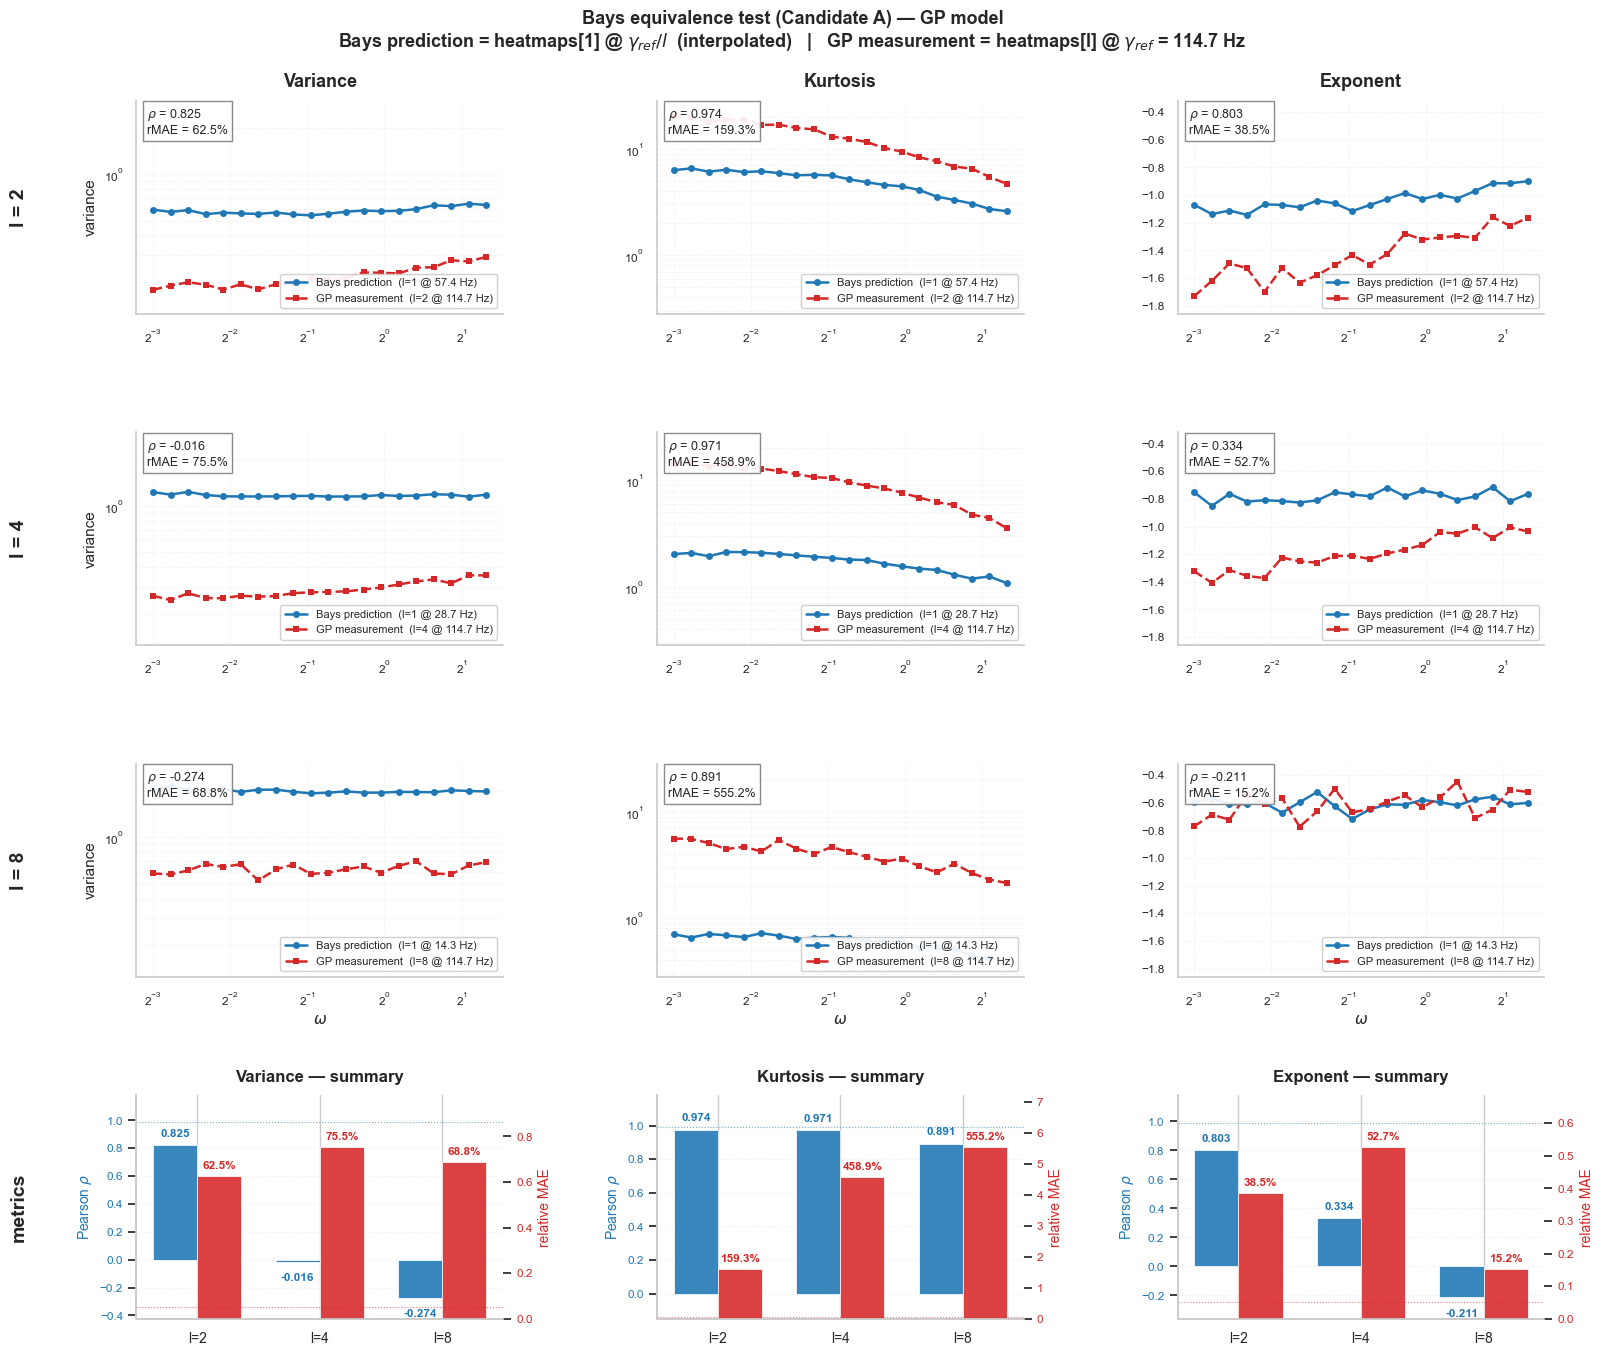

In [13]:
# ---- Visual comparison: prediction vs measurement (Candidate A) ----
#
# BLUE  (solid, circles)  = Bays prediction: heatmaps[1] @ γ_ref/l (interpolated)
# RED   (dashed, squares) = GP measurement:  heatmaps[l] @ γ_ref

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook',
              rc={'axes.spines.right': False, 'axes.spines.top': False})

COLOR_BAYS = '#1f77b4'   # blue  — Bays prediction
COLOR_GP   = '#d62728'   # red   — GP measurement

fig = plt.figure(figsize=(16, 14))
gs  = fig.add_gridspec(
    4, 3,
    height_ratios=[1, 1, 1, 1.05],
    hspace=0.55, wspace=0.42,
    left=0.09, right=0.97, top=0.93, bottom=0.06,
)

quantities        = [('variance', 'var'), ('kurtosis', 'kur'), ('exponent', 'exp')]
set_sizes_compare = [2, 4, 8]

# ---- Top 3 rows: prediction vs measurement curves ----
for col_idx, (q_name, q_key) in enumerate(quantities):
    # Determine shared y-limits per column so rows are comparable.
    all_vals = []
    for l in set_sizes_compare:
        r = next(rr for rr in results_table if rr['l'] == l)
        all_vals.append(r[f'{q_name}_pred'])
        all_vals.append(r[f'{q_name}_meas'])
    all_vals = np.concatenate(all_vals)
    all_vals = all_vals[np.isfinite(all_vals)]

    if q_name in ('variance', 'kurtosis'):
        # Log scale: pad in log space.
        lo = np.nanmin(all_vals[all_vals > 0]) * 0.7
        hi = np.nanmax(all_vals) * 1.4
    else:
        # Linear (exponent): pad ~10%.
        span = all_vals.max() - all_vals.min()
        lo = all_vals.min() - 0.1 * span
        hi = all_vals.max() + 0.1 * span

    for row_idx, l in enumerate(set_sizes_compare):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        r        = next(rr for rr in results_table if rr['l'] == l)
        vec_pred = r[f'{q_name}_pred']
        vec_meas = r[f'{q_name}_meas']
        g_eff    = r['g_eff']

        ax.plot(
            omegas, vec_pred,
            color=COLOR_BAYS, marker='o', linestyle='-',
            markersize=5, linewidth=1.8, markeredgewidth=0,
            label=f'Bays prediction  (l=1 @ {g_eff:.1f} Hz)',
        )
        ax.plot(
            omegas, vec_meas,
            color=COLOR_GP, marker='s', linestyle='--',
            markersize=5, linewidth=1.8, markeredgewidth=0,
            label=f'GP measurement  (l={l} @ {gamma_ref:.1f} Hz)',
        )

        ax.set_xscale('log', base=2)
        if q_name in ('variance', 'kurtosis'):
            ax.set_yscale('log')
        ax.set_ylim(lo, hi)

        if row_idx == 2:
            ax.set_xlabel(r'$\omega$', fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(q_name, fontsize=11)
        ax.tick_params(labelsize=8.5)
        ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.5)

        corr = r[f'{q_name}_corr']
        rmae = r[f'{q_name}_rmae']
        ax.text(
            0.03, 0.97,
            f'$\\rho$ = {corr:.3f}\nrMAE = {rmae:.1%}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(fc='white', ec='gray', alpha=0.92, pad=3),
        )

        ax.legend(fontsize=8, loc='lower right', framealpha=0.92)

        if row_idx == 0:
            ax.set_title(q_name.capitalize(), fontsize=13,
                         fontweight='bold', pad=10)
        if col_idx == 0:
            ax.text(
                -0.32, 0.5, f'l = {l}',
                transform=ax.transAxes, fontsize=14,
                fontweight='bold', va='center', ha='center', rotation=90,
            )

# ---- Bottom row: summary bars ----
ls    = np.array([r['l'] for r in results_table])
x_pos = np.arange(len(ls))
bar_w = 0.36

for col_idx, (q_name, q_key) in enumerate(quantities):
    ax  = fig.add_subplot(gs[3, col_idx])
    ax2 = ax.twinx()

    corrs = np.array([r[f'{q_name}_corr'] for r in results_table])
    rmaes = np.array([r[f'{q_name}_rmae'] for r in results_table])

    bars1 = ax.bar(
        x_pos - bar_w/2, corrs, bar_w,
        color=COLOR_BAYS, alpha=0.88, label=r'$\rho$',
        edgecolor='white', linewidth=0.6,
    )
    bars2 = ax2.bar(
        x_pos + bar_w/2, rmaes, bar_w,
        color=COLOR_GP, alpha=0.88, label='rMAE',
        edgecolor='white', linewidth=0.6,
    )

    rmae_max = max(rmaes.max(), 1e-9)
    for b, v in zip(bars1, corrs):
        y = v + 0.04 if v >= 0 else v - 0.08
        ax.text(
            b.get_x() + b.get_width()/2, y, f'{v:.3f}',
            ha='center', va='bottom' if v >= 0 else 'top',
            fontsize=8.5, color=COLOR_BAYS, fontweight='bold',
        )
    for b, v in zip(bars2, rmaes):
        ax2.text(
            b.get_x() + b.get_width()/2, v + rmae_max * 0.03,
            f'{v:.1%}', ha='center', va='bottom',
            fontsize=8.5, color=COLOR_GP, fontweight='bold',
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'l={l}' for l in ls], fontsize=10)
    ax.set_ylabel(r'Pearson $\rho$', color=COLOR_BAYS, fontsize=10)
    ax2.set_ylabel('relative MAE',   color=COLOR_GP,   fontsize=10)
    ax.tick_params(axis='y', labelcolor=COLOR_BAYS, labelsize=8.5)
    ax2.tick_params(axis='y', labelcolor=COLOR_GP,   labelsize=8.5)
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(True, axis='y', linestyle=':', linewidth=0.5, alpha=0.5)
    ax2.grid(False)

    rho_lo = min(corrs.min(), 0) - 0.15
    ax.set_ylim(rho_lo, 1.18)
    ax2.set_ylim(0, rmae_max * 1.30)

    ax.axhline(0.99, color=COLOR_BAYS, linestyle=':', linewidth=0.8, alpha=0.6)
    ax2.axhline(0.05, color=COLOR_GP,  linestyle=':', linewidth=0.8, alpha=0.6)

    ax.set_title(q_name.capitalize() + ' — summary',
                 fontsize=12, fontweight='bold', pad=10)

    if col_idx == 0:
        ax.text(
            -0.32, 0.5, 'metrics',
            transform=ax.transAxes, fontsize=14,
            fontweight='bold', va='center', ha='center', rotation=90,
        )

fig.suptitle(
    f'Bays equivalence test (Candidate A) — {TUNING.upper()} model\n'
    f'Bays prediction = heatmaps[1] @ $\\gamma_{{ref}}/l$  (interpolated)   |   '
    f'GP measurement = heatmaps[l] @ $\\gamma_{{ref}}$ = {gamma_ref:.1f} Hz',
    fontsize=13, fontweight='bold', y=0.995,
)

plt.savefig(f'fig1_equivalence_candA_{TUNING}.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ---- Tabular view of the prediction/measurement vectors ----
#
# For each set size l ∈ {2, 4, 8} and each metric (variance, kurtosis,
# exponent), show the 20-element prediction and measurement vectors over
# omega side-by-side, plus their absolute and relative differences.

import pandas as pd

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 12)

quantities = [('variance', 'var'), ('kurtosis', 'kur'), ('exponent', 'exp')]

# ---- Per-(l, metric) detailed tables: rows = omega, cols = pred/meas/diffs ----
detail_tables = {}

for l in set_sizes_compare:
    r     = next(rr for rr in results_table if rr['l'] == l)
    g_eff = r['g_eff']

    for q_name, q_key in quantities:
        pred = r[f'{q_name}_pred']
        meas = r[f'{q_name}_meas']
        diff = meas - pred
        rdiff = diff / (np.abs(pred) + 1e-15)

        df = pd.DataFrame({
            'omega':         omegas,
            'lambda':        np.sqrt(omegas),
            'Bays_pred':     pred,
            'GP_meas':       meas,
            'abs_diff':      diff,
            'rel_diff':      rdiff,
        })
        df.index.name = 'i'
        detail_tables[(l, q_name)] = df

        print()
        print('═' * 92)
        print(f"  l = {l}   |   metric = {q_name:<9s}   |   "
              f"γ_eff = {g_eff:.3f} Hz   |   γ_ref = {gamma_ref:.2f} Hz")
        print(f"  ρ = {r[f'{q_name}_corr']:.4f}     "
              f"rMAE = {r[f'{q_name}_rmae']:.2%}     "
              f"MAE = {r[f'{q_name}_mae']:.5f}")
        print('═' * 92)
        print(df.to_string(formatters={
            'omega':     '{:.4f}'.format,
            'lambda':    '{:.4f}'.format,
            'Bays_pred': '{:+.5f}'.format,
            'GP_meas':   '{:+.5f}'.format,
            'abs_diff':  '{:+.5f}'.format,
            'rel_diff':  '{:+.2%}'.format,
        }))

# ---- Compact summary across all (l, metric) combinations ----
print()
print('═' * 92)
print('  SUMMARY — correlation and relative MAE per (l, metric)')
print('═' * 92)

summary_rows = []
for l in set_sizes_compare:
    r = next(rr for rr in results_table if rr['l'] == l)
    summary_rows.append({
        'l':              l,
        'γ_eff (Hz)':     r['g_eff'],
        'var ρ':          r['variance_corr'],
        'var rMAE':       r['variance_rmae'],
        'kur ρ':          r['kurtosis_corr'],
        'kur rMAE':       r['kurtosis_rmae'],
        'exp ρ':          r['exponent_corr'],
        'exp rMAE':       r['exponent_rmae'],
    })
summary_df = pd.DataFrame(summary_rows).set_index('l')
print(summary_df.to_string(formatters={
    'γ_eff (Hz)': '{:.3f}'.format,
    'var ρ':      '{:+.4f}'.format,
    'var rMAE':   '{:.2%}'.format,
    'kur ρ':      '{:+.4f}'.format,
    'kur rMAE':   '{:.2%}'.format,
    'exp ρ':      '{:+.4f}'.format,
    'exp rMAE':   '{:.2%}'.format,
}))

# Display the last detail table inline as a styled DataFrame so Jupyter
# renders it nicely (handy for the live demo).
print()
print('Inline DataFrame (l=8, exponent) shown below for Jupyter rendering:')
detail_tables[(8, 'exponent')]


════════════════════════════════════════════════════════════════════════════════════════════
  l = 2   |   metric = variance    |   γ_eff = 57.365 Hz   |   γ_ref = 114.73 Hz
  ρ = 0.8254     rMAE = 62.46%     MAE = 0.36352
════════════════════════════════════════════════════════════════════════════════════════════
    omega lambda Bays_pred  GP_meas abs_diff rel_diff
i                                                    
0  0.1250 0.3536  +0.59118 +0.17879 -0.41240  -69.76%
1  0.1463 0.3826  +0.57150 +0.19028 -0.38122  -66.70%
2  0.1713 0.4139  +0.58710 +0.20007 -0.38704  -65.92%
3  0.2006 0.4479  +0.55260 +0.19311 -0.35949  -65.05%
4  0.2349 0.4846  +0.56558 +0.17951 -0.38607  -68.26%
5  0.2750 0.5244  +0.55829 +0.19395 -0.36434  -65.26%
6  0.3219 0.5674  +0.55475 +0.18004 -0.37471  -67.55%
7  0.3769 0.6139  +0.56613 +0.19417 -0.37197  -65.70%
8  0.4413 0.6643  +0.55019 +0.19685 -0.35335  -64.22%
9  0.5166 0.7188  +0.54291 +0.20987 -0.33304  -61.34%
10 0.6049 0.7777  +0.55619 +0.20612

,omega,lambda,Bays_pred,GP_meas,abs_diff,rel_diff
i,,,,,,
0,0.1250,0.3536,-0.5949,-0.7704,-0.1755,-0.2951
1,0.1463,0.3826,-0.5715,-0.6861,-0.1146,-0.2006
2,0.1713,0.4139,-0.6112,-0.7234,-0.1122,-0.1836
3,0.2006,0.4479,-0.6104,-0.5381,0.0723,0.1184
4,0.2349,0.4846,-0.6021,-0.6117,-0.0096,-0.0160
5,0.2750,0.5244,-0.6727,-0.5674,0.1053,0.1565
6,0.3219,0.5674,-0.5975,-0.7736,-0.1761,-0.2948
7,0.3769,0.6139,-0.5228,-0.6630,-0.1402,-0.2681
8,0.4413,0.6643,-0.6251,-0.4998,0.1253,0.2004


## Gamma Lengthscale - Variability for Multi-Set Size Experiment

In [24]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'   # macOS Accelerate
os.environ['NUMEXPR_NUM_THREADS'] = '1'

In [ ]:
# ============================================================
# Multi-set-size heatmaps — GP method with controlled variability
# ============================================================
# N_THETA forced to 64 locally — Cholesky at N_THETA=256 is prohibitively
# slow in the current environment (~3.4s per neuron, ~80 hours total).
# At N_THETA=64 each Cholesky is ~64× faster and the orientation grid
# (5.6°/bin) remains well below the variance floor we're measuring.

N_THETA_LOCAL   = 64                     # <-- the win
GP_METHOD       = 'gamma'
GP_VARIABILITY  = 0.5

N_LOCATIONS_GAMMA   = 8
SET_SIZES_GAMMA     = [1, 2, 4, 8]
GAMMA_REF_IDX_GAMMA = 12
SEED_GAMMA          = 42

print(f"N_THETA (local): {N_THETA_LOCAL}  (global is {N_THETA})", flush=True)
print(f"GP method:       {GP_METHOD}", flush=True)
print(f"GP variability:  {GP_VARIABILITY}", flush=True)
print(f"Reference γ_total = {gammas_total[GAMMA_REF_IDX_GAMMA]:.2f} Hz "
      f"(index {GAMMA_REF_IDX_GAMMA})", flush=True)
print(f"Set sizes: {SET_SIZES_GAMMA}", flush=True)
print(f"Grid: {N_GRID}×{N_GRID}, {N_TRIALS:,} trials per pixel", flush=True)
print(flush=True)

_gamma_params = {
    "M": M,
    "N_THETA": N_THETA_LOCAL,            # <-- in cache key, not global
    "N_TRIALS": N_TRIALS,
    "T_D": T_D,
    "SIGMA_SQ": SIGMA_SQ,
    "N_GRID": N_GRID,
    "OMEGA_RANGE": list(OMEGA_RANGE),
    "GAMMA_TOTAL_RANGE": list(GAMMA_TOTAL_RANGE),
    "TUNING": "gp",
    "N_LOCATIONS_GAMMA": N_LOCATIONS_GAMMA,
    "SET_SIZES_GAMMA": list(SET_SIZES_GAMMA),
    "GP_METHOD": GP_METHOD,
    "GP_VARIABILITY": GP_VARIABILITY,
    "SEED_GAMMA": SEED_GAMMA,
}

_cached_gamma = load_cache("multi_heatmap_gamma", _gamma_params)

if _cached_gamma is not None:
    print(f"  [cache HIT] multi_heatmap_gamma  "
          f"(method={GP_METHOD}, var={GP_VARIABILITY}, "
          f"N_THETA={N_THETA_LOCAL})", flush=True)
    heatmaps_gamma = {}
    for l in SET_SIZES_GAMMA:
        heatmaps_gamma[l] = {
            "var": _cached_gamma[f"l{l}_var"],
            "kur": _cached_gamma[f"l{l}_kur"],
            "exp": _cached_gamma[f"l{l}_exp"],
        }
    print(f"  Loaded heatmaps for set sizes {SET_SIZES_GAMMA}", flush=True)
else:
    print(f"  [cache MISS] multi_heatmap_gamma  "
          f"(method={GP_METHOD}, var={GP_VARIABILITY}, "
          f"N_THETA={N_THETA_LOCAL}) — recomputing…", flush=True)
    heatmaps_gamma = {}
    t0_all = time.time()

    for l in SET_SIZES_GAMMA:
        var_grid_l = np.full((N_GRID, N_GRID), np.nan)
        kur_grid_l = np.full((N_GRID, N_GRID), np.nan)
        var_half_l = np.full((N_GRID, N_GRID), np.nan)

        t0_l = time.time()
        print(f"{'='*60}", flush=True)
        print(f"  Set size l = {l}  "
              f"(method={GP_METHOD}, var={GP_VARIABILITY}, "
              f"N_THETA={N_THETA_LOCAL})", flush=True)
        print(f"{'='*60}", flush=True)

        for i, omega in enumerate(omegas):
            t_pop = time.time()
            pop = Population(
                M, N_THETA_LOCAL, omega,           # <-- local N_THETA
                tuning_type='gp',
                n_locations=N_LOCATIONS_GAMMA,
                seed=SEED_GAMMA + i * 1000,
                lengthscale_variability=GP_VARIABILITY,
                gain_variability=0.0,
                method=GP_METHOD,
            )
            t_pop = time.time() - t_pop
            print(f"    [{i+1}/{N_GRID}] ω={omega:.3f} (λ={np.sqrt(omega):.3f})  "
                  f"pop built in {t_pop:.1f}s", flush=True)

            t_trials = time.time()
            for j, gam in enumerate(gammas):
                rng  = np.random.RandomState(
                    SEED_GAMMA + l * 100000 + i * N_GRID + j)
                rng2 = np.random.RandomState(
                    SEED_GAMMA + l * 100000 + i * N_GRID + j + N_GRID**2)

                errors = pop.run_trials(
                    N_TRIALS, gam, T_D,
                    set_size=l, sigma_sq=SIGMA_SQ, rng=rng)
                errors_half = pop.run_trials(
                    N_TRIALS, gam / 2, T_D,
                    set_size=l, sigma_sq=SIGMA_SQ, rng=rng2)

                var_grid_l[j, i] = circular_variance_fisher(errors)
                kur_grid_l[j, i] = circular_kurtosis_fisher(errors)
                var_half_l[j, i] = circular_variance_fisher(errors_half)

            t_trials = time.time() - t_trials
            elapsed_l = time.time() - t0_l
            eta_l = elapsed_l / (i + 1) * (N_GRID - i - 1)
            print(f"         trials: {t_trials:.1f}s  "
                  f"[l={l} elapsed {elapsed_l:.0f}s, ETA {eta_l:.0f}s]",
                  flush=True)

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio_l = np.where(var_half_l > 1e-15,
                               var_grid_l / var_half_l, np.nan)
            exp_grid_l = np.where(ratio_l > 0, np.log2(ratio_l), np.nan)

        heatmaps_gamma[l] = {'var': var_grid_l,
                             'kur': kur_grid_l,
                             'exp': exp_grid_l}

        elapsed_total = time.time() - t0_all
        print(f"  l={l} done in {time.time() - t0_l:.0f}s  "
              f"(total elapsed: {elapsed_total:.0f}s)", flush=True)
        print(flush=True)

    print(f"\nAll set sizes done in {time.time() - t0_all:.0f}s", flush=True)

    _save_payload = {}
    for l in SET_SIZES_GAMMA:
        _save_payload[f"l{l}_var"] = heatmaps_gamma[l]["var"]
        _save_payload[f"l{l}_kur"] = heatmaps_gamma[l]["kur"]
        _save_payload[f"l{l}_exp"] = heatmaps_gamma[l]["exp"]
    save_cache("multi_heatmap_gamma", _gamma_params, _save_payload)

print(f"\nDone. Variable: heatmaps_gamma[l] = {{'var', 'kur', 'exp'}}",
      flush=True)